In [2]:
!pip install -U pandas numpy matplotlib scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: pandas
    Found existing installation: pand

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.impute import SimpleImputer

from scipy.spatial.distance import squareform  # to convert full distance matrix to condensed form


In [8]:
# graphichs
%matplotlib inline

# seed for repeatability
RANDOM_STATE = 42

# **1. Cluster Analysis**

# **1.1. kMeans / kModes / kPrototypes Clustering**

# Load data and select features (no feature engineering)

In [13]:
df = pd.read_excel('/content/fish_market_cleaned.xlsx')

In [9]:
# Drop target and any derived log_* columns: we only keep raw feature space for clustering
target_col = "Weight"
log_cols = [c for c in df.columns if c.startswith("log_")]

In [10]:
# X will contain both numeric and the single categorical 'Species'
X_raw = df.drop(columns=log_cols + [target_col]).copy()

In [11]:
# Identify column types (1 categorical + several numeric)
categorical_cols = [c for c in X_raw.columns if X_raw[c].dtype == "object"]
numeric_cols = [c for c in X_raw.columns if c not in categorical_cols]

In [12]:
display(df.head())
print("Categorical columns:", categorical_cols)
print("Numeric columns     :", numeric_cols)

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801


Categorical columns: ['Species']
Numeric columns     : ['Length1', 'Length2', 'Length3', 'Height', 'Width', 'Volume']


##  Minimal preprocessing: impute + scale + one‑hot
*HINT: do NOT engineer new features; we only make the data usable for k-means*

In [14]:
# Simple imputation: numeric -> mean, categorical -> most frequent
from sklearn.impute import SimpleImputer

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [29]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_proc = preprocess.fit_transform(X_raw)
print("Processed feature matrix shape:", X_proc.shape)

Processed feature matrix shape: (159, 13)


## Elbow curve (k=2..10) and pick best

In [18]:
k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_proc)
    inertias.append(km.inertia_)

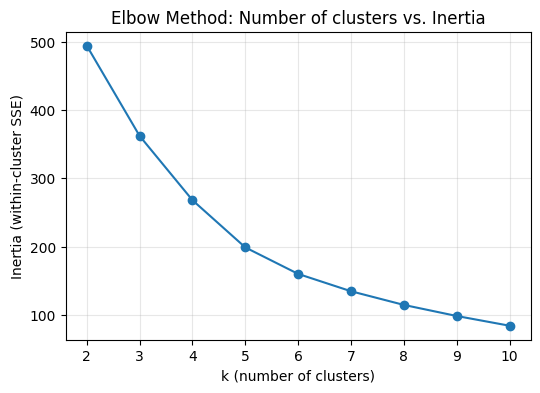

In [19]:
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method: Number of clusters vs. Inertia")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.grid(alpha=0.3)
plt.show()

In [23]:
# Simple knee heuristic: pick k after the largest relative drop
rel_drops = [(inertias[i-1] - inertias[i]) / inertias[i-1] for i in range(1, len(inertias))]
best_k = k_values[np.argmax(rel_drops) + 1]  # +1 for the shift
print(f"Selected k (heuristic) (approximately equal) ~ {best_k}")

Selected k (heuristic) (approximately equal) ~ 3


## Fit k‑Means with best k and output DataFrame

In [24]:
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_proc)

In [76]:
# Attach cluster labels back to original data frame
df_km = df.copy()
df_km["Cluster_kmeans"] = cluster_labels

In [75]:
print(f"k-means trained with k={best_k}.")
display(df_km.head())

k-means trained with k=3.


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,Cluster_kmeans
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0


In [27]:
# df_out.to_csv("kmeans_clusters_output.csv", index=False)

# **1.2. Hierarchical Clustering**

In [30]:
X_dense = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc
print("Processed feature matrix shape:", X_dense.shape)

Processed feature matrix shape: (159, 13)


## Euclidean: single, complete, ward dendrograms

In [33]:
Z_single_euclid   = linkage(X_dense, method="single",   metric="euclidean")
Z_complete_euclid = linkage(X_dense, method="complete", metric="euclidean")
Z_ward_euclid     = linkage(X_dense, method="ward")  # Ward assumes Euclidean

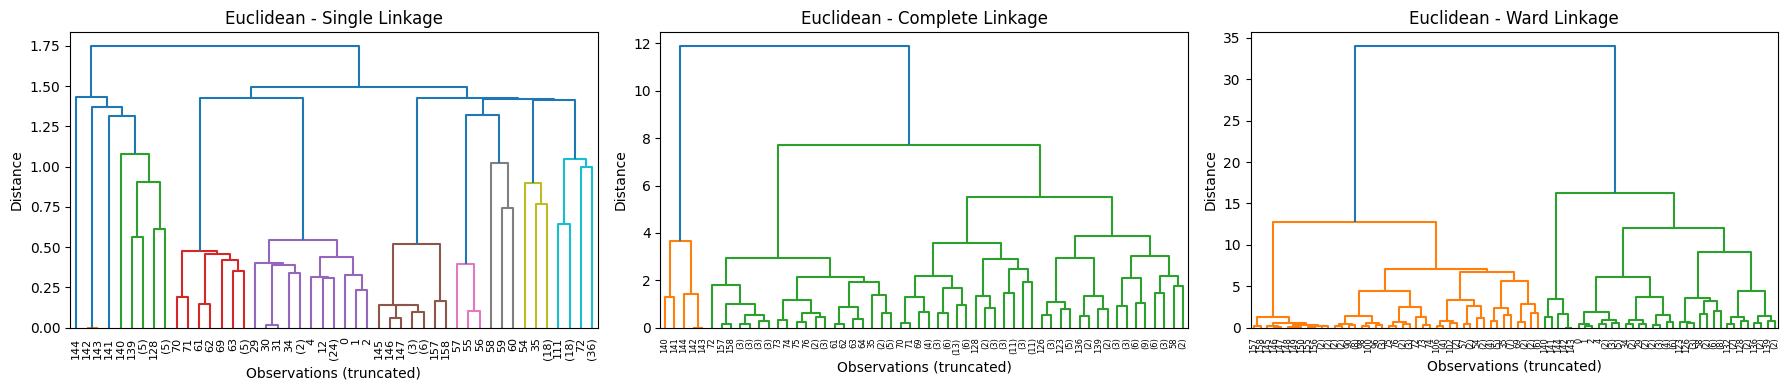

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, Z, title in zip(
    axes,
    [Z_single_euclid, Z_complete_euclid, Z_ward_euclid],
    ["Euclidean - Single Linkage", "Euclidean - Complete Linkage", "Euclidean - Ward Linkage"]
):
    dendrogram(Z, ax=ax, truncate_mode="level", p=6)
    ax.set_title(title)
    ax.set_xlabel("Observations (truncated)")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

* **Single** sometimes creates a chaining effect and can form long branches.
* **Complete** prefers more compact clusters.
* **Ward** minimizes the total intravariance; it generally gives stable results in our dataset.




## Gower distance for mixed-type data (average & complete)

In [35]:
def gower_distance_matrix(df_mix, cat_cols, num_cols):
    """
    Compute Gower distance for mixed-type data.
    Numeric features are range-normalized; categorical features use 0/1 mismatch.
    Returns a full (n x n) symmetric distance matrix with zeros on the diagonal.
    """
    n = df_mix.shape[0]
    num_arr = df_mix[num_cols].to_numpy(dtype=float)
    cat_arr = df_mix[cat_cols].astype(str).to_numpy()

    # Range normalization for numeric features
    ranges = num_arr.max(axis=0) - num_arr.min(axis=0)
    ranges[ranges == 0] = 1.0  # avoid division by zero

    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        diff_num = np.abs(num_arr[i] - num_arr) / ranges if num_arr.size else 0.0
        diff_cat = (cat_arr[i] != cat_arr).astype(float) if cat_arr.size else 0.0

        num_sum = diff_num.sum(axis=1) if isinstance(diff_num, np.ndarray) else 0.0
        cat_sum = diff_cat.sum(axis=1) if isinstance(diff_cat, np.ndarray) else 0.0

        m = len(num_cols) + len(cat_cols)
        D[i, :] = (num_sum + cat_sum) / m

    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    return D

In [36]:
D_gower = gower_distance_matrix(X_raw, categorical_cols, numeric_cols)
print("Gower distance matrix shape:", D_gower.shape)


Gower distance matrix shape: (159, 159)


In [37]:
# Convert full distance matrix to condensed form for scipy.linkage
D_gower_condensed = squareform(D_gower, checks=False)

# Average and Complete linkage on Gower distances
Z_avg_gower     = linkage(D_gower_condensed, method="average")   # metric implied by condensed distances
Z_complete_gower= linkage(D_gower_condensed, method="complete")

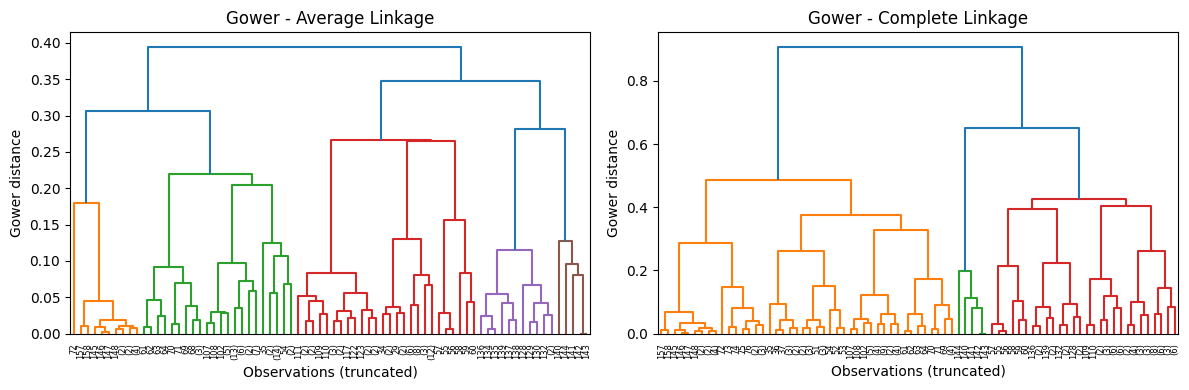

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, title in zip(
    axes,
    [Z_avg_gower, Z_complete_gower],
    ["Gower - Average Linkage", "Gower - Complete Linkage"]
):
    dendrogram(Z, ax=ax, truncate_mode="level", p=6)
    ax.set_title(title)
    ax.set_xlabel("Observations (truncated)")
    ax.set_ylabel("Gower distance")
plt.tight_layout()
plt.show()

## Choose recommended k and output cluster assignments (DataFrame)

In [39]:
K_RECOMMENDED = 3  # adjust if needed

In [40]:
# fcluster with 'maxclust' so that we cut the tree into K_RECOMMENDED clusters
labels_single_euclid   = fcluster(Z_single_euclid,   t=K_RECOMMENDED, criterion="maxclust")
labels_complete_euclid = fcluster(Z_complete_euclid, t=K_RECOMMENDED, criterion="maxclust")
labels_ward_euclid     = fcluster(Z_ward_euclid,     t=K_RECOMMENDED, criterion="maxclust")

labels_avg_gower       = fcluster(Z_avg_gower,       t=K_RECOMMENDED, criterion="maxclust")
labels_complete_gower  = fcluster(Z_complete_gower,  t=K_RECOMMENDED, criterion="maxclust")

In [41]:
# Attach all labels to a single output DataFrame
df_hc = df.copy()
df_hc["HC_Single_Euclid"]    = labels_single_euclid
df_hc["HC_Complete_Euclid"]  = labels_complete_euclid
df_hc["HC_Ward_OneHot"]      = labels_ward_euclid
df_hc["HC_Average_Gower"]    = labels_avg_gower
df_hc["HC_Complete_Gower"]   = labels_complete_gower

print(f"Cluster assignments created with K={K_RECOMMENDED}.")
display(df_hc.head())

Cluster assignments created with K=3.


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,HC_Single_Euclid,HC_Complete_Euclid,HC_Ward_OneHot,HC_Average_Gower,HC_Complete_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,2,3,3,2,3
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,2,3,3,2,3
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,2,3,3,2,3
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,2,3,3,2,3
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,2,3,3,2,3


In [42]:
df_hc.to_csv(f"hierarchical_clusters_K{K_RECOMMENDED}.csv", index=False)

# **1.3. DBScan Clustering **

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## DBSCAN hyperparameter search on Gower distance

In [45]:
# Define search grids
eps_grid = np.linspace(0.05, 0.35, 13)      # finer grid
min_samples_grid = [3, 4, 5, 6, 7, 8, 10]   # a few reasonable values

results = []
n = D_gower.shape[0]

[GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/)

[Look at again for exam](https://www.youtube.com/watch?v=RDZUdRSDOok)

In [47]:
for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(ms), metric='precomputed')
        labels = db.fit_predict(D_gower)

        # basic stats
        unique = np.unique(labels)
        clusters = [u for u in unique if u != -1]
        n_clusters = len(clusters)
        noise_ratio = (labels == -1).sum() / n

        # compute metrics on non-noise subset (silhouette with precomputed distances)
        sil = np.nan
        dbi = np.nan
        ch  = np.nan

        mask = labels != -1
        if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
            # Silhouette using precomputed Gower submatrix
            D_sub = D_gower[np.ix_(mask, mask)]
            sil = silhouette_score(D_sub, labels[mask], metric='precomputed')

            # Davies-Bouldin & Calinski-Harabasz require feature vectors; use X_proc subset
            # Assumes X_proc exists from previous steps (scaled numeric + one-hot categorical)
            try:
                dbi = davies_bouldin_score(X_proc[mask], labels[mask])
                ch  = calinski_harabasz_score(X_proc[mask], labels[mask])
            except Exception:
                pass

        results.append({
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": float(sil) if sil == sil else np.nan,
            "davies_bouldin": float(dbi) if dbi == dbi else np.nan,
            "calinski_harabasz": float(ch) if ch == ch else np.nan
        })

In [48]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(["silhouette"], ascending=False).head(10))

,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
6,0.05,10,5,0.270440,0.760323,0.576315,292.035554
97,0.05,10,5,0.270440,0.760323,0.576315,292.035554
96,0.05,8,5,0.238994,0.735678,0.622433,251.401994
5,0.05,8,5,0.238994,0.735678,0.622433,251.401994
3,0.05,6,7,0.125786,0.730459,0.633250,195.606613
94,0.05,6,7,0.125786,0.730459,0.633250,195.606613
95,0.05,7,6,0.176101,0.730373,0.646763,208.562015
4,0.05,7,6,0.176101,0.730373,0.646763,208.562015
2,0.05,5,8,0.088050,0.714787,0.620163,176.393571
1,0.05,4,8,0.088050,0.714787,0.620163,176.393571


## Select best configuration and fit final DBSCAN

In [49]:
# A practical selection rule:
# 1) at least 2 clusters
# 2) reasonable noise ratio (e.g., <= 0.5)
# 3) maximize silhouette
# 4) if tie, prefer n_clusters close to K ~ 3 from earlier steps

K_TARGET = 3

candidates = results_df[
    (results_df["n_clusters"] >= 2) &
    (results_df["noise_ratio"] <= 0.5) &
    (~results_df["silhouette"].isna())
].copy()

In [50]:
if candidates.empty:
    # Fallback: relax noise constraint
    candidates = results_df[~results_df["silhouette"].isna()].copy()

# Tie-break: score silhouette + small bonus if n_clusters == K_TARGET
candidates["score"] = candidates["silhouette"] + np.where(candidates["n_clusters"] == K_TARGET, 0.02, 0.0)


In [51]:
best_row = candidates.sort_values(["score", "silhouette"], ascending=False).iloc[0]
best_eps = float(best_row["eps"])
best_ms  = int(best_row["min_samples"])

print("Selected DBSCAN config -> eps:", best_eps, "| min_samples:", best_ms)
print("Stats -> n_clusters:", int(best_row["n_clusters"]),
      "| noise_ratio:", round(float(best_row["noise_ratio"]), 3),
      "| silhouette:", round(float(best_row["silhouette"]), 3))

Selected DBSCAN config -> eps: 0.05 | min_samples: 10
Stats -> n_clusters: 5 | noise_ratio: 0.27 | silhouette: 0.76


In [52]:
# Fit final DBSCAN with the chosen params
db_best = DBSCAN(eps=best_eps, min_samples=best_ms, metric='precomputed')
db_labels = db_best.fit_predict(D_gower)

In [53]:
db_best

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",10
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'precomputed'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [54]:
db_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4])

In [55]:
# Attach to a copy of df
df_db = df.copy()
df_db["DBSCAN_Gower"] = db_labels
display(df_db.head())

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,DBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,0
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0


## HDBSCAN (Gower, precomputed)

In [59]:
import hdbscan

# HDBSCAN can accept precomputed distances. We pass the full Gower matrix.
# We'll try a small grid for min_cluster_size and min_samples.
mcs_grid = [5, 7, 10]     # min_cluster_size
ms_grid  = [1, 5, 7, 10]  # min_samples (0/None means default behavior)

hdb_results = []

In [61]:
for mcs in mcs_grid:
    for ms in ms_grid:
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs,
                              min_samples=ms,
                              metric='precomputed',
                              cluster_selection_method='eom')  # standard choice
        hdb_labels = hdb.fit_predict(D_gower)

        unique = np.unique(hdb_labels)
        clusters = [u for u in unique if u != -1]
        n_clusters = len(clusters)
        noise_ratio = (hdb_labels == -1).sum() / n

        sil = np.nan
        dbi = np.nan
        ch  = np.nan

        mask = hdb_labels != -1
        if mask.sum() >= 2 and len(np.unique(hdb_labels[mask])) >= 2:
            D_sub = D_gower[np.ix_(mask, mask)]
            sil = silhouette_score(D_sub, hdb_labels[mask], metric='precomputed')
            try:
                dbi = davies_bouldin_score(X_proc[mask], hdb_labels[mask])
                ch  = calinski_harabasz_score(X_proc[mask], hdb_labels[mask])
            except Exception:
                pass

        hdb_results.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": float(sil) if sil == sil else np.nan,
            "davies_bouldin": float(dbi) if dbi == dbi else np.nan,
            "calinski_harabasz": float(ch) if ch == ch else np.nan
        })

In [62]:
hdb_df = pd.DataFrame(hdb_results)
display(hdb_df.sort_values(["silhouette"], ascending=False).head(10))

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
3,5,10,7,0.106918,0.722780,0.660760,171.800362
7,7,10,7,0.106918,0.722780,0.660760,171.800362
19,7,10,7,0.106918,0.722780,0.660760,171.800362
15,5,10,7,0.106918,0.722780,0.660760,171.800362
10,10,7,7,0.069182,0.703241,0.740182,148.455778
14,5,7,7,0.069182,0.703241,0.740182,148.455778
6,7,7,7,0.069182,0.703241,0.740182,148.455778
2,5,7,7,0.069182,0.703241,0.740182,148.455778
18,7,7,7,0.069182,0.703241,0.740182,148.455778
22,10,7,7,0.069182,0.703241,0.740182,148.455778


In [63]:
# Pick the best HDBSCAN config
cand_hdb = hdb_df[
    (hdb_df["n_clusters"] >= 2) &
    (hdb_df["noise_ratio"] <= 0.5) &
    (~hdb_df["silhouette"].isna())
].copy()

In [64]:
if cand_hdb.empty:
    cand_hdb = hdb_df[~hdb_df["silhouette"].isna()].copy()

best_hdb = cand_hdb.sort_values(["silhouette"], ascending=False).iloc[0]
print("Selected HDBSCAN -> mcs:", int(best_hdb["min_cluster_size"]),
      "| ms:", int(best_hdb["min_samples"]))
print("Stats -> n_clusters:", int(best_hdb["n_clusters"]),
      "| noise_ratio:", round(float(best_hdb["noise_ratio"]), 3),
      "| silhouette:", round(float(best_hdb["silhouette"]), 3))


Selected HDBSCAN -> mcs: 5 | ms: 10
Stats -> n_clusters: 7 | noise_ratio: 0.107 | silhouette: 0.723


In [65]:
# Fit the best HDBSCAN to get final labels
hdb_best = hdbscan.HDBSCAN(min_cluster_size=int(best_hdb["min_cluster_size"]),
                           min_samples=int(best_hdb["min_samples"]),
                           metric='precomputed',
                           cluster_selection_method='eom')
hdb_labels = hdb_best.fit_predict(D_gower)


In [66]:
# Attach to df_db alongside DBSCAN
df_db["HDBSCAN_Gower"] = hdb_labels
display(df_db.head())


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,DBSCAN_Gower,HDBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,0,2
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0,2
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0,2
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0,2
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0,2


In [67]:
df_db.to_csv("dbscan_hdbscan_gower_labels.csv", index=False)

## Summary comparison

In [69]:
summary_rows = []

# Compute metrics helper
def compute_metrics_from_labels(labels, name):
    from collections import Counter
    unique = np.unique(labels)
    clusters = [u for u in unique if u != -1]
    n_clusters = len(clusters)
    noise_ratio = (labels == -1).sum() / len(labels)

    mask = labels != -1
    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
        sil = silhouette_score(D_gower[np.ix_(mask, mask)], labels[mask], metric='precomputed')
        dbi = davies_bouldin_score(X_proc[mask], labels[mask])
        ch  = calinski_harabasz_score(X_proc[mask], labels[mask])
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    summary_rows.append([name, n_clusters, noise_ratio, sil, dbi, ch])

# Evaluate both
compute_metrics_from_labels(df_db["DBSCAN_Gower"].to_numpy(), "DBSCAN (Gower)")
compute_metrics_from_labels(df_db["HDBSCAN_Gower"].to_numpy(), "HDBSCAN (Gower)")

summary_df = pd.DataFrame(summary_rows,
                          columns=["Method","#Clusters (excl. noise)","Noise ratio",
                                   "Silhouette (precomputed)","Davies-Bouldin","Calinski-Harabasz"])
display(summary_df.style.format({
    "Noise ratio":"{:.2f}",
    "Silhouette (precomputed)":"{:.3f}",
    "Davies-Bouldin":"{:.3f}",
    "Calinski-Harabasz":"{:.1f}"
}))

,Method,#Clusters (excl. noise),Noise ratio,Silhouette (precomputed),Davies-Bouldin,Calinski-Harabasz
0,DBSCAN (Gower),5,0.27,0.760,0.576,292.0
1,HDBSCAN (Gower),7,0.11,0.723,0.661,171.8


# **1.4. Clustering comparison methods**

## Prepare binary labels for external metrics

In [71]:
# target_col was defined before as weight

# Choose the threshold (limit_value): median is a robust default.
limit_value = df[target_col].median()
y_true = np.where(df[target_col] < limit_value, 1, 2)

print(f"limit_value for '{target_col}' = {limit_value:.3f}")
unique, counts = np.unique(y_true, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

limit_value for 'Weight' = 273.000
Class distribution: {np.int64(1): np.int64(79), np.int64(2): np.int64(80)}


The regression dataset does not have "true classes" for external metrics. As per the instructions, we generate binary classes by thresholding the target variable.

## Gather all cluster labels into a single DataFrame

In [73]:
# Start from the original df and attach the labels from previous steps.
df_all = df.copy()

In [77]:
# k-Means (from Section 1.1)
if "df_km" in globals() and "Cluster_kmeans" in df_km.columns:
    df_all["KMeans"] = df_km["Cluster_kmeans"]
else:
    raise RuntimeError("KMeans labels (df_km['Cluster_kmeans']) not found. Please run Section 1.1 cells.")

In [78]:
# Hierarchical (from Section 1.2)
if "df_hc" in globals():
    expected_hc_cols = ["HC_Single_Euclid", "HC_Complete_Euclid", "HC_Ward_OneHot",
                        "HC_Average_Gower", "HC_Complete_Gower"]
    for col in expected_hc_cols:
        if col in df_hc.columns:
            df_all[col] = df_hc[col]
        else:
            print(f"Warning: '{col}' not found in df_hc.")
else:
    raise RuntimeError("Hierarchical labels (df_hc[...]) not found. Please run Section 1.2 cells.")

In [79]:
# DBSCAN/HDBSCAN (from Section 1.3)
if "df_db" in globals():
    for col in ["DBSCAN_Gower", "HDBSCAN_Gower"]:
        if col in df_db.columns:
            df_all[col] = df_db[col]
        else:
            print(f"Warning: '{col}' not found in df_db.")
else:
    print("Note: df_db not found. If you didn't run DBSCAN/HDBSCAN, those columns will be missing.")

In [80]:
display(df_all.head())

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,...,log_Width,log_Volume,KMeans,HC_Single_Euclid,HC_Complete_Euclid,HC_Ward_OneHot,HC_Average_Gower,HC_Complete_Gower,DBSCAN_Gower,HDBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,...,1.391282,9.780099,1,2,3,3,2,3,0,2
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,...,1.459917,9.888041,0,2,3,3,2,3,0,2
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,...,1.546732,9.888231,0,2,3,3,2,3,0,2
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,...,1.494139,10.148410,0,2,3,3,2,3,0,2
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,...,1.635885,10.170801,0,2,3,3,2,3,0,2


## Metric helpers (internal/external) with proper masking


In [81]:
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
)

In [82]:
def compute_internal_metrics(name, labels, X_proc, D_gower=None, metric_space="euclidean", noise_label=-1):
    """
    Compute internal validation metrics:
    - Silhouette: Euclidean on X_proc OR precomputed Gower on non-noise subset
    - Davies-Bouldin, Calinski-Harabasz: on X_proc (require feature vectors), non-noise subset if needed
    """
    import numpy as np
    metrics = {"Method": name, "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}

    labels = np.asarray(labels)
    # For density-based labels, we usually exclude noise (-1) for internal metrics.
    mask = labels != noise_label if noise_label in labels else np.ones_like(labels, dtype=bool)

    # Need at least 2 clusters among the considered points
    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
        # Silhouette
        if metric_space == "gower" and D_gower is not None:
            D_sub = D_gower[np.ix_(mask, mask)]
            metrics["Silhouette"] = silhouette_score(D_sub, labels[mask], metric="precomputed")
        else:
            metrics["Silhouette"] = silhouette_score(X_proc[mask], labels[mask])
        # DB & CH
        try:
            metrics["Davies-Bouldin"] = davies_bouldin_score(X_proc[mask], labels[mask])
            metrics["Calinski-Harabasz"] = calinski_harabasz_score(X_proc[mask], labels[mask])
        except Exception:
            pass

    return metrics

In [83]:
def compute_external_metrics(name, labels, y_true, noise_label=-1, exclude_noise=True):
    """
    Compute external validation metrics against y_true:
    - Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), Fowlkes-Mallows (FM)
    By default exclude noise (-1) to avoid artifacts on DBSCAN/HDBSCAN.
    """
    import numpy as np
    metrics = {"Method": name, "ARI": np.nan, "NMI": np.nan, "Fowlkes-Mallows": np.nan}

    labels = np.asarray(labels)
    y_arr = np.asarray(y_true)

    if exclude_noise and (noise_label in labels):
        mask = labels != noise_label
    else:
        mask = np.ones_like(labels, dtype=bool)

    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2 and len(np.unique(y_arr[mask])) >= 2:
        metrics["ARI"] = adjusted_rand_score(y_arr[mask], labels[mask])
        metrics["NMI"] = normalized_mutual_info_score(y_arr[mask], labels[mask])
        metrics["Fowlkes-Mallows"] = fowlkes_mallows_score(y_arr[mask], labels[mask])

    return metrics

## Run metrics for all methods & build summary tables

In [84]:
method_specs = [
    ("KMeans",                   "KMeans",                "euclidean"),
    ("HC - Single (Euclid)",     "HC_Single_Euclid",      "euclidean"),
    ("HC - Complete (Euclid)",   "HC_Complete_Euclid",    "euclidean"),
    ("HC - Ward (OneHot)",       "HC_Ward_OneHot",        "euclidean"),
    ("HC - Average (Gower)",     "HC_Average_Gower",      "gower"),
    ("HC - Complete (Gower)",    "HC_Complete_Gower",     "gower"),
    ("DBSCAN (Gower)",           "DBSCAN_Gower",          "gower"),
    ("HDBSCAN (Gower)",          "HDBSCAN_Gower",         "gower"),
]

internal_rows = []
external_rows = []

In [85]:
for nice_name, col_name, space in method_specs:
    if col_name not in df_all.columns:
        # Method not available (e.g., you may have skipped DBSCAN/HDBSCAN)
        continue
    labels = df_all[col_name].to_numpy()

    # Internal metrics
    internal_rows.append(
        compute_internal_metrics(nice_name, labels, X_proc, D_gower=D_gower, metric_space=space, noise_label=-1)
    )
    # External metrics
    external_rows.append(
        compute_external_metrics(nice_name, labels, y_true, noise_label=-1, exclude_noise=True)
    )

In [86]:
internal_df = pd.DataFrame(internal_rows)
external_df = pd.DataFrame(external_rows)

In [87]:
print("Internal validation metrics:")
display(internal_df.style.format({"Silhouette":"{:.3f}","Davies-Bouldin":"{:.3f}","Calinski-Harabasz":"{:.1f}"}))

print("External validation metrics (noise excluded for density-based methods):")
display(external_df.style.format({"ARI":"{:.3f}","NMI":"{:.3f}","Fowlkes-Mallows":"{:.3f}"}))

Internal validation metrics:


,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.481,0.730,154.4
1,HC - Single (Euclid),0.242,1.321,43.1
2,HC - Complete (Euclid),0.316,0.748,85.7
3,HC - Ward (OneHot),0.479,0.707,149.8
4,HC - Average (Gower),0.456,1.012,134.2
5,HC - Complete (Gower),0.426,0.718,145.6
6,DBSCAN (Gower),0.760,0.576,292.0
7,HDBSCAN (Gower),0.723,0.661,171.8


External validation metrics (noise excluded for density-based methods):


,Method,ARI,NMI,Fowlkes-Mallows
0,KMeans,0.766,0.714,0.879
1,HC - Single (Euclid),0.192,0.192,0.577
2,HC - Complete (Euclid),0.181,0.304,0.629
3,HC - Ward (OneHot),0.711,0.626,0.851
4,HC - Average (Gower),0.611,0.541,0.791
5,HC - Complete (Gower),0.690,0.593,0.840
6,DBSCAN (Gower),0.352,0.474,0.597
7,HDBSCAN (Gower),0.267,0.396,0.520


In [88]:
# Merge for a single summary table if you like
summary_df = pd.merge(internal_df, external_df, on="Method", how="outer")
display(summary_df.style.format({
    "Silhouette":"{:.3f}","Davies-Bouldin":"{:.3f}","Calinski-Harabasz":"{:.1f}",
    "ARI":"{:.3f}","NMI":"{:.3f}","Fowlkes-Mallows":"{:.3f}"
}))

,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Fowlkes-Mallows
0,DBSCAN (Gower),0.760,0.576,292.0,0.352,0.474,0.597
1,HC - Average (Gower),0.456,1.012,134.2,0.611,0.541,0.791
2,HC - Complete (Euclid),0.316,0.748,85.7,0.181,0.304,0.629
3,HC - Complete (Gower),0.426,0.718,145.6,0.690,0.593,0.840
4,HC - Single (Euclid),0.242,1.321,43.1,0.192,0.192,0.577
5,HC - Ward (OneHot),0.479,0.707,149.8,0.711,0.626,0.851
6,HDBSCAN (Gower),0.723,0.661,171.8,0.267,0.396,0.520
7,KMeans,0.481,0.730,154.4,0.766,0.714,0.879


## Cluster–class cross-tabulation for each method

In [89]:
def cluster_class_crosstab(labels, y_true, method_name):
    """
    Produce a cross-tabulation (counts) of cluster vs. class.
    Includes noise as a separate row if present.
    """
    import pandas as pd
    tab = pd.crosstab(pd.Series(labels, name="Cluster"), pd.Series(y_true, name="Class"))
    print(f"\n=== {method_name}: Cluster–Class Crosstab ===")
    display(tab)
    return tab

In [90]:
crosstabs = {}
for nice_name, col_name, _ in method_specs:
    if col_name in df_all.columns:
        labels = df_all[col_name].to_numpy()
        crosstabs[nice_name] = cluster_class_crosstab(labels, y_true, nice_name)


=== KMeans: Cluster–Class Crosstab ===


Class,1,2
Cluster,,
0,0,67
1,79,7
2,0,6



=== HC - Single (Euclid): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
1,1,16
2,10,36
3,68,28



=== HC - Complete (Euclid): Cluster–Class Crosstab ===


...

Class,1,2
Cluster,,
1,75,7
2,0,5
3,4,68



=== DBSCAN (Gower): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
-1,16,27
0,1,31
1,17,1
2,31,3
3,0,18
4,14,0



=== HDBSCAN (Gower): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
-1,7,10
0,1,12
1,14,0
2,1,34
3,7,1
4,18,1
5,31,4
6,0,18


## Simple interpretability checks

In [91]:
# Inspect how numeric features differ across clusters for a chosen method (e.g., KMeans)
inspect_method = "KMeans"  # change to another col, e.g., "HC_Ward_OneHot"
if inspect_method in df_all.columns:
    tmp = pd.concat([X_raw[numeric_cols], X_raw[categorical_cols], df_all[inspect_method]], axis=1)
    tmp = tmp.rename(columns={inspect_method: "Cluster"})
    print(f"\nNumeric feature means by cluster — {inspect_method}")
    display(tmp.groupby("Cluster")[numeric_cols].mean().round(2))
    if categorical_cols:
        cat = categorical_cols[0]
        print(f"\n{cat} distribution by cluster — {inspect_method}")
        display(pd.crosstab(tmp["Cluster"], tmp[cat]))


Numeric feature means by cluster — KMeans


,Length1,Length2,Length3,Height,Width,Volume
Cluster,,,,,,
0,33.32,36.05,40.02,12.71,5.80,50165.63
1,18.89,20.50,22.35,6.02,3.20,10360.94
2,52.68,56.52,60.33,9.55,6.38,184329.74



Species distribution by cluster — KMeans


Species,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
Cluster,,,,,,,
0,34,0,19,10,1,0,3
1,1,11,37,1,19,14,3
2,0,0,0,6,0,0,0
